In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

#### SIMPLE LINEAR REGRESSION MODEL

In [12]:
# read the dataset
df = pd.read_csv('../../height-weight.csv')
df.head(4)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145


Text(0.5, 0, 'Height')

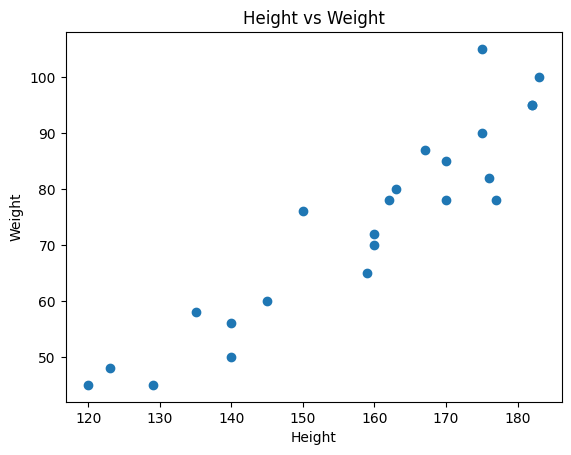

In [13]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
# sns.regplot(x='Height', y='Weight', data=df)
plt.xlabel('Height')

In [14]:
# divide dataset into independent and dependent features
X = df[['Weight']]
y = df['Height']

In [15]:
# train test split
from sklearn.model_selection import train_test_split

In [16]:
# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [17]:
# standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test = scaler.transform(X_test.values.reshape(-1, 1))

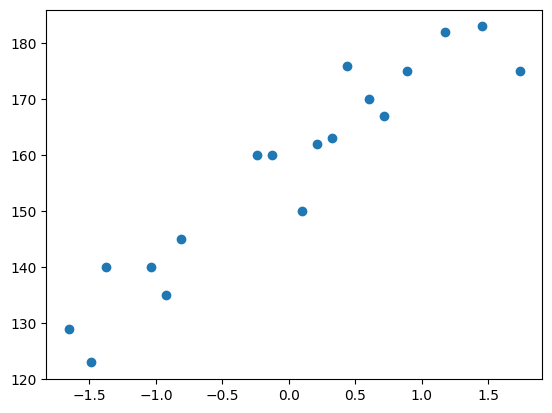

In [21]:
plt.scatter(X_train, y_train)

In [22]:
# Train the simple linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')


Mean Squared Error: 109.77592599051664
R^2 Score: 0.776986986042344


In [24]:
# print the intercept and coefficient
print(f'Intercept: {model.intercept_}')
print(f'Coefficient: {model.coef_[0]}')

Intercept: 157.5
Coefficient: 17.034408719095538


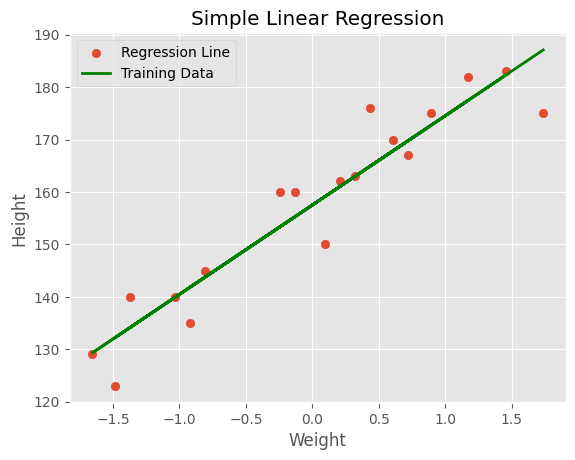

In [31]:
plt.scatter(X_train, y_train)
plt.title('Simple Linear Regression')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.plot(X_train, model.predict(X_train), color='green', linewidth=2)
plt.legend(['Regression Line', 'Training Data'])
plt.style.use('ggplot')
plt.show()

In [ ]:
# Assumptions of Linear Regression:
# 1. Linearity: The relationship between the independent and dependent variables should be linear.
# 2. Independence: The residuals (errors) should be independent of each other.
# 3. Homoscedasticity: The residuals should have constant variance at every level of the independent variable.
# 4. Normality: The residuals should be approximately normally distributed.


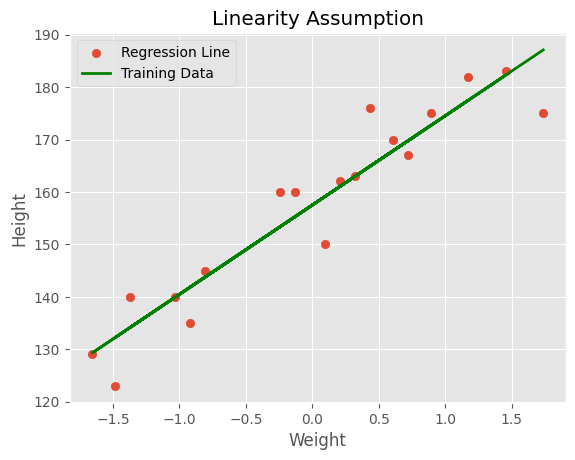

In [33]:

# proove the assumptions of linear regression with the help of plots and statistical tests.
# 1. Linearity
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color='green', linewidth=2)
plt.title('Linearity Assumption')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend(['Regression Line', 'Training Data'])
plt.style.use('ggplot')
plt.show()


Durbin-Watson Statistic: 1.106648643133049


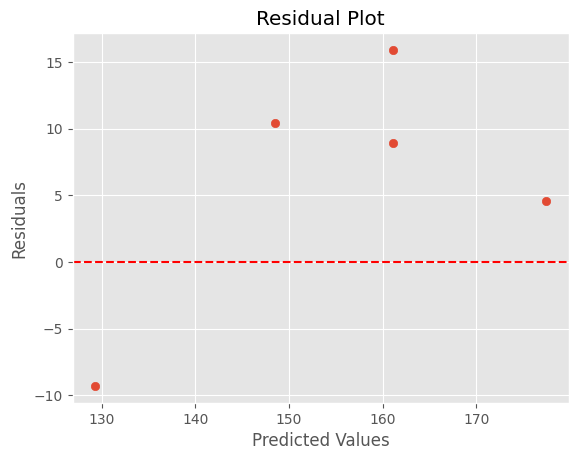

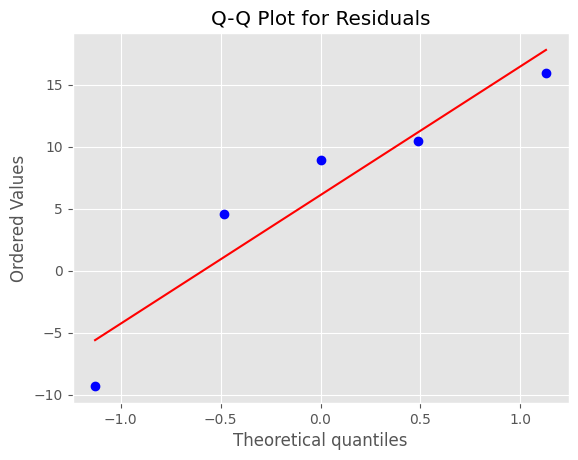

In [34]:
# 2. Independence
# We can use the Durbin-Watson test to check for independence of residuals.
from statsmodels.stats.stattools import durbin_watson
residuals = y_test - y_pred
dw_statistic = durbin_watson(residuals)
print(f'Durbin-Watson Statistic: {dw_statistic}')
# 3. Homoscedasticity
# We can create a residual plot to check for homoscedasticity.
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.style.use('ggplot')
plt.show()
# 4. Normality
# We can create a Q-Q plot to check for normality of residuals.
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals')
plt.style.use('ggplot')
plt.show()
